In [113]:
from langgraph.graph import StateGraph , START,END
from typing import TypedDict
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
import os
import json

In [114]:
load_dotenv()
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

In [124]:
DATABASE_NAME = "buisness_analytics"
engine = create_engine(
    "postgresql://amishiranjan@localhost:5432/buisness_analytics"
)

In [116]:
class AnalyticsState(TypedDict):
    file_path:str
    df: pd.DataFrame
    data_report:dict
    
    database_name: str
    table_name: str
    upload_status: str

    generated_queries: str

    query_results: dict


In [117]:
def load_file(state:AnalyticsState) -> AnalyticsState:
    
    file_path = state["file_path"]
    if file_path.endswith(".csv"):
        df = pd.read_csv(file_path)
    elif file_path.endswith(".json"):
        df = pd.read_json(file_path)
    else:
        raise ValueError("Unsupported file format")
    
    
    state["df"] = df
    return state


In [118]:
def data_clean(state:AnalyticsState) -> AnalyticsState:
    df = state["df"]
    report={
        "rows": len(df),
        "columns": len(df.columns),
        "missing_values": df.isnull().sum().to_dict(),
        "total_missing": int(df.isnull().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum())
    }
    state["data_report"] = report
    return state


In [119]:
def upload_to_db(state:AnalyticsState) -> AnalyticsState:
    DATABASE_NAME = "buisness_analytics"
    df = state["df"]
    # sales.csv -> sales
    filename = os.path.basename(state["file_path"])

    table_name = (
        os.path.splitext(filename)[0]
        .lower()
        .replace(" ", "_")
    )

    df.to_sql(
        table_name,
        con=engine,
        if_exists="replace",
        index=False
    )

    state["database_name"] = DATABASE_NAME
    state["table_name"] = table_name

    state["upload_status"] = (
        f"{len(df)} rows uploaded to "
        f"{DATABASE_NAME}.{table_name}"
    )

    return state

In [120]:
def llm_layer(state:AnalyticsState) -> AnalyticsState:
    df = state["df"]

    prompt = f"""
    You are an expert business analyst.
    Dataset Schema:
    {df.dtypes.astype(str).to_dict()}
    
    Sample Data:
    {df.head(10).to_dict(orient="records")}
    Analyze the dataset and determine the most valuable insights that can be extracted.

    Generate the TOP 5 SQL queries that would provide the highest analytical value.

    Requirements:
    - Do not assume any industry or business domain.
    - Use only available columns.
    - Each query should answer a different analytical question.
    - Prefer meaningful aggregations, trends, rankings, comparisons,
      correlations, segmentations, or anomaly detection.
    - Assume the SQLite table name is 'data'.
    - Return ONLY valid JSON.

    Necessary:
    All column names must be wrapped in double quotes exactly as shown in the schema.


    Required Output Format:

[
  {{
    "title": "Insight Name",
    "query": "SELECT ..."
  }},
  {{
    "title": "Insight Name",
    "query": "SELECT ..."
  }}
]
"""
    response = model.invoke(prompt)

    state["generated_queries"] = response.content

    return {
        "generated_queries": response.content
    }


In [121]:
import json

def execute_query(state: AnalyticsState) -> AnalyticsState:
    try:
        cleaned = state["generated_queries"]
        cleaned = cleaned.replace("```json", "")
        cleaned = cleaned.replace("```", "")
        cleaned = cleaned.strip()
        queries = json.loads(cleaned)
    except (json.JSONDecodeError, TypeError) as e:
        print(f"Error parsing generated queries: {e}")

        return {
            "query_results": {}
        }

    results = {}

    for q in queries:
        title = q["title"]
        sql = q["query"]

        sql = sql.replace("data", state["table_name"])

        try:
            result_df = pd.read_sql(sql, engine)

            results[title] = result_df

            print(f"\n=== {title} ===")
            print(result_df.head(10))

        except Exception as e:
            print(f"Error in {title}: {e}")

    return {
        "query_results": results
    }

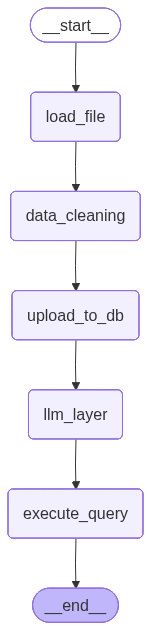

In [122]:
graph = StateGraph(AnalyticsState)

# Nodes
graph.add_node("load_file", load_file)
graph.add_node("data_cleaning", data_clean)
graph.add_node("upload_to_db", upload_to_db)
graph.add_node("llm_layer", llm_layer)
graph.add_node("execute_query", execute_query)  


# Edges
graph.add_edge(START, "load_file")
graph.add_edge("load_file", "data_cleaning")
graph.add_edge("data_cleaning", "upload_to_db")
graph.add_edge("upload_to_db", "llm_layer")
graph.add_edge("llm_layer", "execute_query")
graph.add_edge("execute_query", END)

graph.compile()

In [123]:
workflow=graph.compile()
initial_state={"file_path":"leads.csv"}
final_state=workflow.invoke(initial_state)
print(final_state["data_report"])
print(final_state["generated_queries"])
final_state["query_results"]


=== Top Lead Owners by Assigned Leads ===
        Lead Owner  Total Leads
0    Roberta Keith            4
1    Carmen Bowers            4
2   Travis Salazar            4
3    Melody Larsen            4
4    Kelli Webster            4
5   Phillip Mccann            4
6  Melanie Pearson            4
7        Tom Nolan            4
8      Norman Pope            4
9   Joanna Manning            4

=== Companies with Multiple Associated Leads ===
              Company  Number of Leads
0        Morton Group               16
1      Richardson PLC               16
2          Page Group               15
3          Reilly Ltd               15
4     Suarez and Sons               15
5          Cortez Inc               15
6           Jones Inc               15
7  Donaldson and Sons               14
8        Martin Group               14
9          Ortega Inc               14

=== Overall Contact Information Completeness ===
   Percentage with Any Phone  Percentage with Email  Percentage with Website

{'Top Lead Owners by Assigned Leads':            Lead Owner  Total Leads
 0       Roberta Keith            4
 1       Carmen Bowers            4
 2      Travis Salazar            4
 3       Melody Larsen            4
 4       Kelli Webster            4
 ...               ...          ...
 93185    Patty Osborn            1
 93186  Bailey Maynard            1
 93187  Regina Jenkins            1
 93188     Chloe Klein            1
 93189     Jill Graves            1
 
 [93190 rows x 2 columns],
 'Companies with Multiple Associated Leads':                 Company  Number of Leads
 0          Morton Group               16
 1        Richardson PLC               16
 2            Page Group               15
 3            Reilly Ltd               15
 4       Suarez and Sons               15
 ...                 ...              ...
 6381        Gill-Obrien                2
 6382  Bradford-Griffith                2
 6383           Hood Ltd                2
 6384       Anderson PLC              